In [5]:
import pandas as pd

properties=pd.read_csv("Estate-Sales.csv")
properties.head(10)

,_id,PARID,FULL_ADDRESS,PROPERTYHOUSENUM,PROPERTYFRACTION,PROPERTYADDRESSDIR,PROPERTYADDRESSSTREET,PROPERTYADDRESSSUF,PROPERTYADDRESSUNITDESC,PROPERTYUNITNO,...,MUNIDESC,RECORDDATE,SALEDATE,PRICE,DEEDBOOK,DEEDPAGE,SALECODE,SALEDESC,INSTRTYP,INSTRTYPDESC
0,77445779,0060H00156000000,"233 E MEYERS ST, PITTSBURGH, PA 15210",233,,E,MEYERS,ST,NaN,NaN,...,29th Ward - PITTSBURGH,2014-01-27,2014-01-27,35000,15498,100,37,ESTATE SALE,DE,DEED
1,77446338,0096E00224000000,"1136 CREEDMOOR AVE, PITTSBURGH, PA 15226",1136,,NaN,CREEDMOOR,AVE,NaN,NaN,...,19th Ward - PITTSBURGH,2014-01-24,2014-01-24,31200,15497,211,37,ESTATE SALE,FD,FIDUCIARY DEED
2,77446450,0004H00229000000,"0 WILLIAM ST, PITTSBURGH, PA 15203",0,,NaN,WILLIAM,ST,NaN,NaN,...,18th Ward - PITTSBURGH,2014-02-03,2014-02-03,60000,15505,511,37,ESTATE SALE,DE,DEED
3,77446581,0016F00076000000,"983 TROPICAL AVE, PITTSBURGH, PA 15216",983,,NaN,TROPICAL,AVE,NaN,NaN,...,19th Ward - PITTSBURGH,2014-01-29,2014-01-29,70000,15500,371,37,ESTATE SALE,DE,DEED
4,77446934,0047A00195000000,"1114 FABYAN ST, PITTSBURGH, PA 15212",1114,,NaN,FABYAN,ST,NaN,NaN,...,26th Ward - PITTSBURGH,2013-09-19,2013-09-19,20000,15379,115,37,ESTATE SALE,FD,FIDUCIARY DEED
5,77448316,0082M00146000000,"1221 MILLBRAE WAY, PITTSBURGH, PA 15206",1221,,NaN,MILLBRAE,WAY,NaN,NaN,...,11th Ward - PITTSBURGH,2014-02-20,2014-02-20,45000,15519,1,37,ESTATE SALE,DE,DEED
6,77449165,0052E00011061600,"128 N CRAIG ST, UNIT 616, PITTSBURGH, PA 15213",128,,N,CRAIG,ST,UNIT,616,...,4th Ward - PITTSBURGH,2014-03-03,2014-03-03,106425,15527,245,37,ESTATE SALE,DE,DEED
7,77449282,0068H00234000000,"251 BALVER AVE, PITTSBURGH, PA 15205",251,,NaN,BALVER,AVE,NaN,NaN,...,28th Ward - PITTSBURGH,2014-03-13,2014-03-13,124900,15539,192,37,ESTATE SALE,DE,DEED
8,77449725,0115D00222000000,"3870 EAST ST, PITTSBURGH, PA 15214",3870,,NaN,EAST,ST,NaN,NaN,...,26th Ward - PITTSBURGH,2014-03-13,2014-03-13,16500,15538,217,37,ESTATE SALE,DE,DEED
9,77450002,0042N00168000000,"1221 FAIRDALE ST, PITTSBURGH, PA 15204",1221,,NaN,FAIRDALE,ST,NaN,NaN,...,20th Ward - PITTSBURGH,2014-03-13,2014-03-13,12000,15538,588,37,ESTATE SALE,DE,DEED


In [6]:

import geopandas
from shapely.geometry import Point
ZIPS = geopandas.read_file("https://data.wprdc.org/dataset/1a5135de-cabe-4e23-b5e4-b2b8dd733817/resource/ec228c0e-6b1e-4f44-a335-df05546d52ea/download/alcogisallegheny-county-zip-code-boundaries.zip")
NEIGHBORHOODS = geopandas.read_file("https://data.wprdc.org/dataset/e672f13d-71c4-4a66-8f38-710e75ed80a4/resource/c5a93a8e-03d7-4eb3-91a8-c6b7db0fa261/download/pittsburghpaneighborhoods-.zip").to_crs(ZIPS.crs)

def zip_to_neighborhoods(zip_code):
    """Converts a ZIP code to a list of Pittsburgh neighborhood names.

    Args:
        zip_code (int): The ZIP code of interest.

    Returns:
        list[str]: A list of neighborhood names within that ZIP code.
    """
    # Get this specific zip
    zips_filtered = ZIPS[ZIPS["ZIP"] == str(zip_code)]
    if len(zips_filtered) < 1:
        return None
    zp = zips_filtered.iloc[0]
    # List of neighborhoods for this zip
    zp_neighborhoods = []
    # Loop through the neighborhoods
    for _idx, neighborhood in NEIGHBORHOODS.iterrows():
        # Check if this zip intersects the neighborhood
        if neighborhood["geometry"].intersects(zp["geometry"]):
            # Add this neighborhood to the list
            zp_neighborhoods.append(neighborhood["hood"])
    return zp_neighborhoods

this shows the amount of Estate sales within each neighborhood in the city of pittsburgh

<Axes: xlabel='Neighborhoods'>

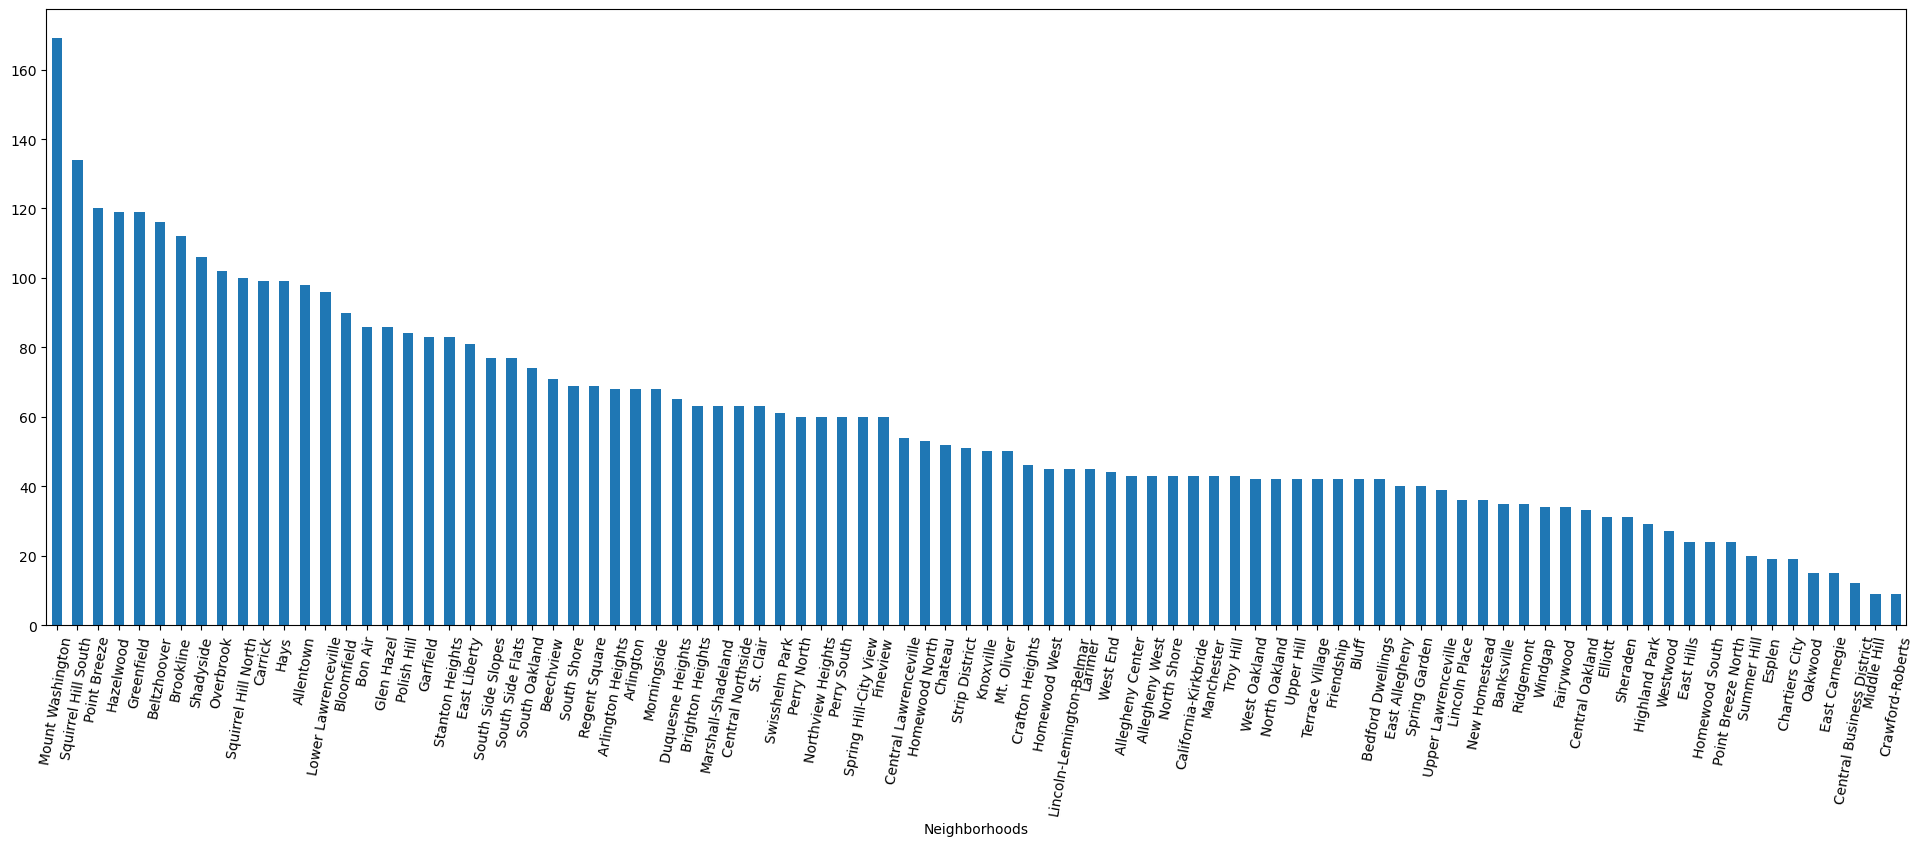

In [7]:
properties["Neighborhoods"] = properties["PROPERTYZIP"].astype(str).apply(zip_to_neighborhoods)
properties = properties.explode("Neighborhoods")
prop_counts = properties["Neighborhoods"].value_counts()
prop_counts.plot(kind = "bar", figsize = (24,8),rot = 80)

<Axes: xlabel='Neighborhoods'>

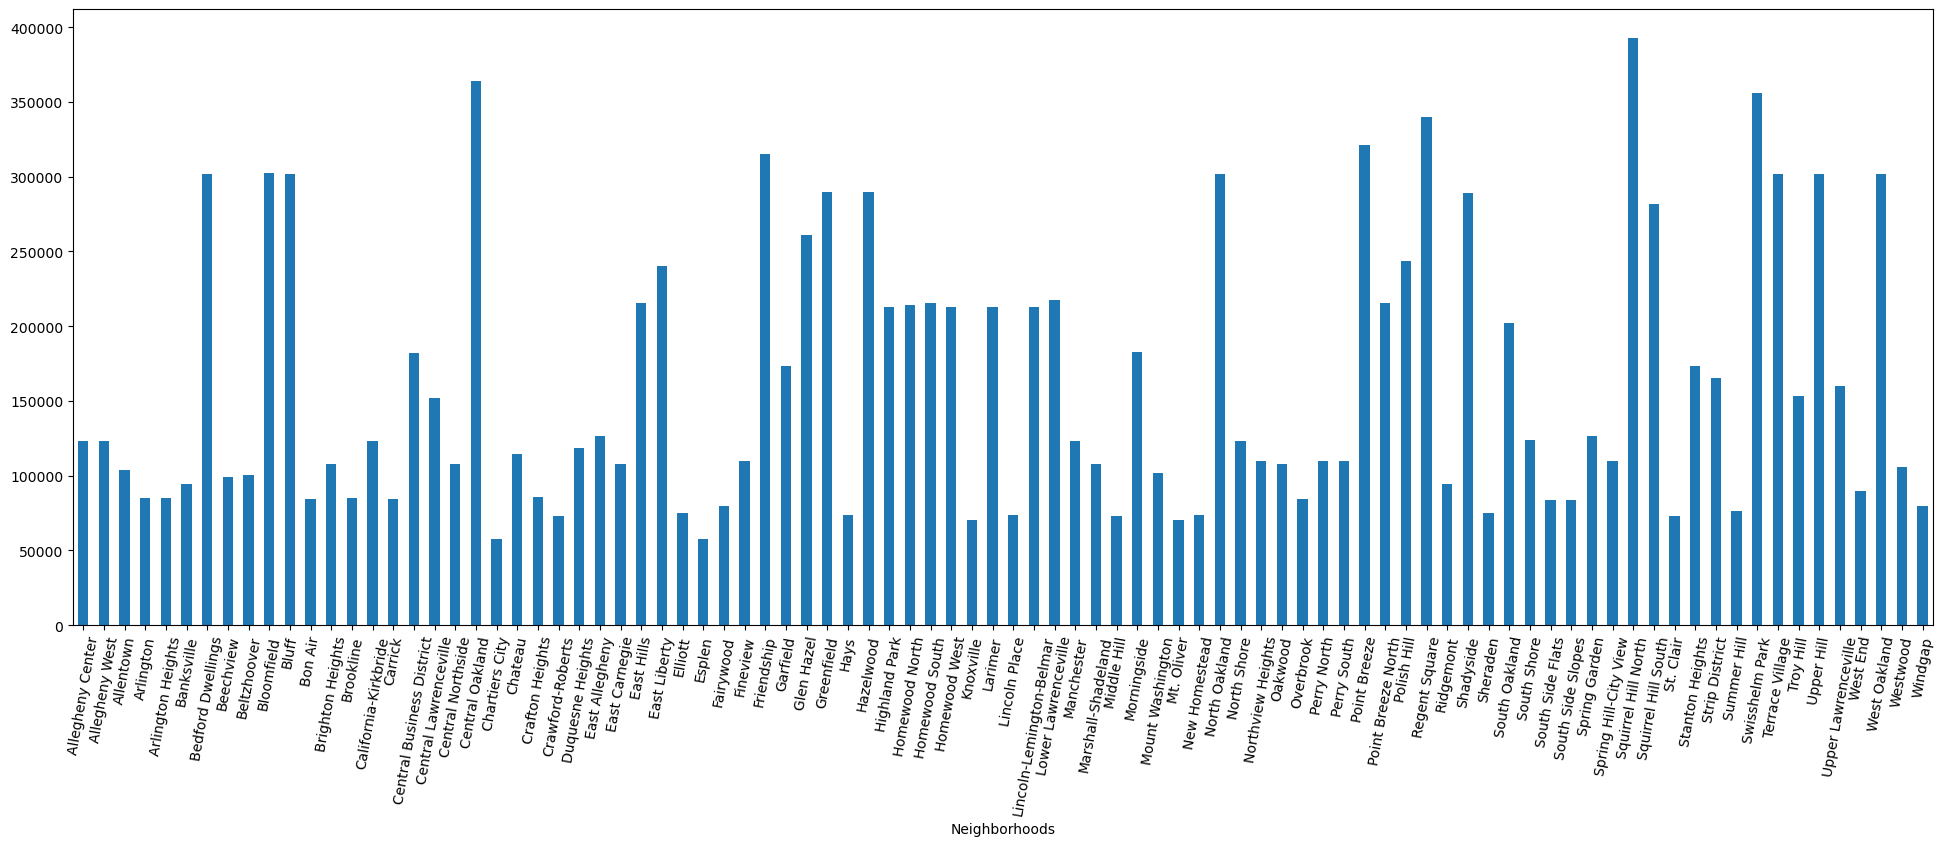

In [8]:
average_sale = properties.groupby("Neighborhoods")["PRICE"].mean()
average_sale.plot(kind = "bar", figsize = (24,8),rot = 80)

In [11]:
top10avgsale = average_sale.sort_values(ascending = False).head(10)
print(top10avgsale)

Neighborhoods
Squirrel Hill North    392550.420000
Central Oakland        364036.060606
Swisshelm Park         355895.672131
Regent Square          340146.898551
Point Breeze           321520.058333
Friendship             315178.357143
Bloomfield             302246.455556
Bluff                  301695.000000
North Oakland          301695.000000
Bedford Dwellings      301695.000000
Name: PRICE, dtype: float64
